# Simulate individual parcellations
Simulations of individual parcellations to find optimal parameters for estimating functional reponse profiles of regions (V estimation) and estimating individual parcellations (Uhat estimation)

In [1]:
import numpy as np
import torch as pt
import matplotlib.pyplot as plt
import seaborn as sb
import IndividualParcellation.scripts.paths as paths
import HierarchBayesParcel.full_model as fm
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.arrangements as ar
import HierarchBayesParcel.spatial as sp
import ProbabilisticParcellation.util as ut
import pandas as pd
from copy import deepcopy


/Users/callithrix/code/Python/IndividualParcellation/env/lib/python3.9/site-packages/torch/__init__.py:614: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/tensor/python_tensor.cpp:453.)
  _C._set_default_tensor_type(t)


# Fusion dataset kappas
Inspect kappa from real datasets to get an estimate of normal range for kappa

In [2]:
# Load model to inspect the kappas
model_name = f'/Models_03/NettekovenSym32_space-MNISymC2'
info, model = ut.load_batch_best(model_name)
info = ut.recover_info(info, model, model_name)
model.emissions[0].kappa

# print all kappas
data_dir = paths.set_fusion_dir()
T = pd.read_csv(data_dir + '/dataset_description.tsv', sep='\t')
datasets = T.name.repeat(T.num_sess).tolist()

kappas = []
for i,emission in enumerate(model.emissions):
    print(f'{datasets[i]}, {emission.kappa.item()}')
    kappas.append(emission.kappa.item())
print(f'Mean: {np.mean(kappas)}')
print(f'Std: {np.std(kappas)}')
# Print range
print(f'Min: {np.min(kappas)} Max: {np.max(kappas)}')

MDTB, 14.993122100830078
MDTB, 20.03233528137207
Pontine, 7.986279010772705
Nishimoto, 50.17647933959961
Nishimoto, 56.90852355957031
IBC, 9.472673416137695
IBC, 3.2918500900268555
IBC, 11.218647956848145
IBC, 6.20421838760376
IBC, 5.385562419891357
IBC, 12.21861743927002
IBC, 9.17889404296875
IBC, 5.476701736450195
IBC, 5.781688690185547
IBC, 5.3336663246154785
IBC, 1.981207251548767
IBC, 4.702580451965332
IBC, 3.6129379272460938
IBC, 2.276122808456421
WMFS, 4.12080717086792
WMFS, 15.732511520385742
Demand, 16.219104766845703
Somatotopic, 8.740423202514648
Mean: 12.219345865042314
Std: 13.640576700304967
Min: 1.981207251548767 Max: 56.90852355957031


# Simulations


In [49]:
K=32
n_subj=8
# low = 0.1
# # high = 10
# low = 0.2
# high = 5


In [67]:
# Load and concatenate all simulations
base_dir = paths.set_base_dir()
results_dir = paths.set_results_dir(base_dir)

n_simulation = 1
noise_levels = [(0.2, 1)]
simulations = []
for low, high in noise_levels:
    filename = f'simulate_V-estimation_K-{K}_nsub-{n_subj}_kappa-{low}-{high}_sim-{n_simulation}'
    df = pd.read_csv(results_dir + f'evaluation/{filename}.csv')
    df['noise_level'] = f'{low}-{high}'
    simulations.append(df)

df = pd.concat(simulations)
df['noise_level'] = df['noise_level'].astype('category')
df.to_csv(results_dir + f'evaluation/simulate_V-estimation_K-{K}_nsub-{n_subj}_kappa-all-{n_simulation}.csv', index=False, sep='\t')

# -- Or load specific simulation -- 
# low, high = noise_levels[0]
# filename = f'simulate_V-estimation_K-{K}_nsub-{n_subj}_kappa-{low}-{high}_sim-{n_simulation}'
# df = pd.read_csv(results_dir + f'evaluation/{filename}.csv')
# df.head()


## Data types for simulated data

| Data Type              | Subject-Specific Kappa | Parcel-Specific Kappa | Subjects Equal Weight | Kappa                 |
|------------------------|------------------------|-----------------------|-----------------------|-----------------------|
| General                    | False                  | False                 | False                 | 20                    |
| Subject-Specific Same Low  | True                   | False                 | False                 | [4, 4, 4, ...]   |
| Subject-Specific Same High | True                   | False                 | False                 | [20, 20, 20, ...]   |
| Subject-Specific One       | True                   | False                 | False                 | [4, 20, 20, 20, ...] |
| Subject-Specific Half      | True                   | False                 | False                 | [4, 4, ..., 20, 20] |
| Parcel-Specific Same Low   | False                  | True                  | False                 | [4, 4, 4, ...]   |
| Parcel-Specific Same High  | False                  | True                  | False                 | [20, 20, 20, ...]   |
| Parcel-Specific One        | False                  | True                  | False                 | [4, 20, 20, 20, ...] |

## Model types for simulated parameter recovery 

| Model Type          | Subject-Specific Kappa | Parcel-Specific Kappa | Subjects Equal Weight |
|---------------------|------------------------|-----------------------|-----------------------|
| general             | False                  | False                 | False                 |
| general_eq          | False                  | False                 | True                  |
| subject_specific    | True                   | False                 | False                 |
| subject_specific_eq | True                   | False                 | True                  |
| parcel_specific     | False                  | True                  | False                 |



In [68]:
model_types = {                    
                'general':               {'subject_specific_kappa':False, 'parcel_specific_kappa':False, 'subjects_equal_weight':False},
                'general_eq':            {'subject_specific_kappa':False, 'parcel_specific_kappa':False, 'subjects_equal_weight':True},
                'subject_specific':      {'subject_specific_kappa':True, 'parcel_specific_kappa':False, 'subjects_equal_weight':False},
                'subject_specific_eq':   {'subject_specific_kappa':True, 'parcel_specific_kappa':False, 'subjects_equal_weight':True},
                }
data_types = {'general_low': {'subject_specific_kappa':False, 'parcel_specific_kappa':False, 'subjects_equal_weight':False, 'kappa': low},
                    'general_high': {'subject_specific_kappa':False, 'parcel_specific_kappa':False, 'subjects_equal_weight':False, 'kappa': high},
                    'subject_specific_one': {'subject_specific_kappa':True, 'parcel_specific_kappa':False, 'subjects_equal_weight':False, 'kappa': [low] + [high]*int(n_subj-1)},
                    'subject_specific_half': {'subject_specific_kappa':True, 'parcel_specific_kappa':False, 'subjects_equal_weight':False, 'kappa': [low]*int(n_subj/2) + [high]*int(n_subj/2)},
        }

# Helper functions

In [69]:
def recover_subject_kappa(df_kappa, n_subj):
    """Recovers the kappa values for each subject from the dataframe"""

    df_kappa_subject = df_kappa[~df_kappa.data_type.str.startswith('parcel_specific')].reset_index(drop=True)

    # Make kappas into lists of the same length
    for e, entry in enumerate(df_kappa_subject['kappa']):
        if isinstance(entry, str):
            entry = entry.replace('[','').replace(']','').replace('\n','')
            entry = entry.split(', ')
            if len(entry) < n_subj:
                entry = entry[0].split(' ')
                entry = list(filter(None, entry))
                if len(entry) < n_subj:
                    entry = entry*n_subj
            # print(e)
            entry = [float(e) for e in entry]
            df_kappa_subject.at[e,'kappa'] = entry
        elif isinstance(entry, float):
            # print(e)
            df_kappa_subject.at[e,'kappa'] = [entry]*n_subj
    
    # explode kappa into separate rows
    df_kappa_subject = df_kappa_subject.explode('kappa').reset_index(drop=True)
    # add subject number
    df_kappa_subject['subject'] = np.tile(np.arange(n_subj), df_kappa_subject.shape[0]//n_subj)
    # set all entries of model_type where comparison is 'kappa_true' to 'True' for plotting
    df_kappa_subject['model_type'].loc[df_kappa_subject['comparison'] == 'kappa_true'] = 'True'

    return df_kappa_subject

## Estimating functional response profiles (Vs)

In [70]:
# melt 'similarity' (V accuracy),'correct' (Uhat accuracy) and 'kappa' (kappa accuracy) columns into separate rows
df_melted = df.melt(id_vars=['model_type', 'data_type', 'outlier', 'simulation'],
                    value_vars=['similarity_true',
                                'similarity_outlier',
                                'kappa_true',
                                'kappa_estimated',
                                'correct_mean',
                                'correct_outlier', 
                                'correct_mean_normal'], var_name='comparison', value_name='value')
# make separate column with 'comparison' split by '_' into 'metric' and 'parameter'
# df_melted[['parameter', 'comparison']] = df_melted['comparison'].str.split('_', expand=True)
df_melted.head()
df_kappa = df_melted[(df_melted.comparison.str.contains('kappa'))]
df_kappa = df_kappa.rename(columns={'value': 'kappa'})
df_v = df_melted[df_melted.comparison.str.contains('similarity')]
df_v = df_v.rename(columns={'value': 'V_similarity'})
df_uhat = df_melted[df_melted.comparison.str.contains('correct')]
df_uhat = df_uhat.rename(columns={'value': 'Uhat_correct'})

# V estimation

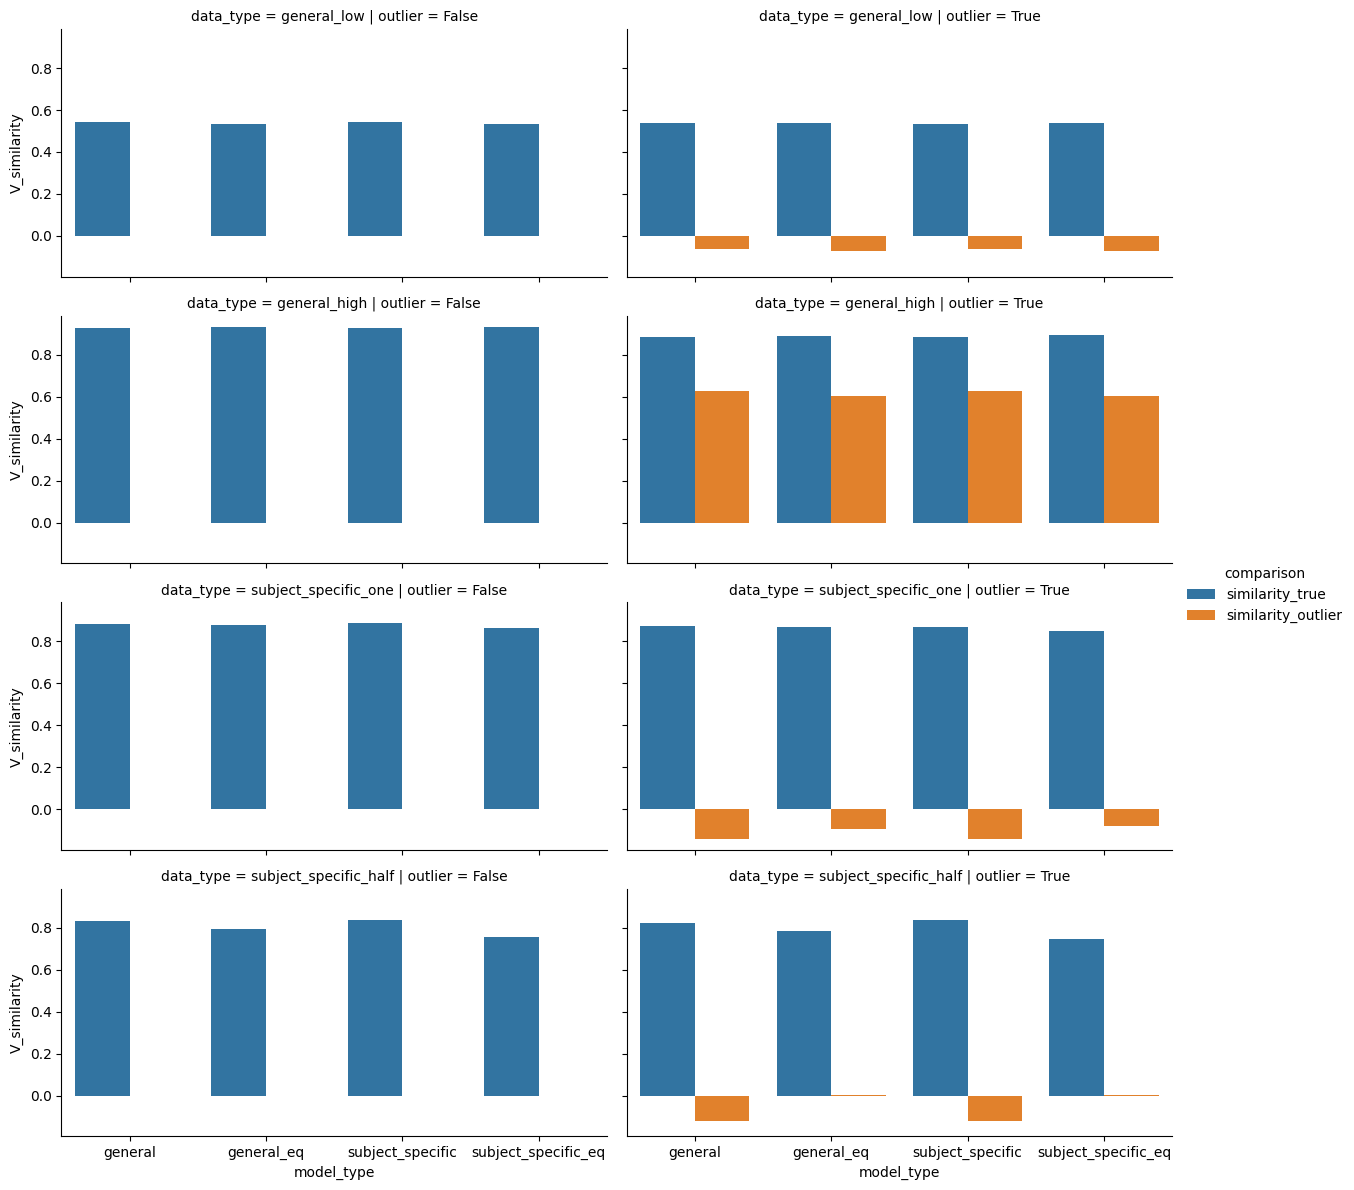

In [71]:
# Plot results
sb.catplot(data=df_v,
            x='model_type',
            y='V_similarity',
            hue='comparison',
            col='outlier',
            row='data_type',
            kind='bar',
            height=3, aspect=2,
            order=list(model_types.keys()))
figure_dir = paths.set_figure_dir()
plt.savefig(figure_dir + f'{filename}.png')
            

In [72]:
df_v.head()

,model_type,data_type,outlier,simulation,comparison,V_similarity
0,general,general_low,True,1,similarity_true,0.538234
1,general_eq,general_low,True,1,similarity_true,0.537946
2,subject_specific,general_low,True,1,similarity_true,0.534865
3,subject_specific_eq,general_low,True,1,similarity_true,0.536693
4,general,general_low,False,2,similarity_true,0.544731


## Print results

In [73]:
data_type='general'
table = df_v.query('data_type == @data_type').pivot_table(index=['model_type', 'outlier'], columns='comparison', values='V_similarity', aggfunc=['mean', 'std'])
table


model_type,outlier


# Kappa Estimation

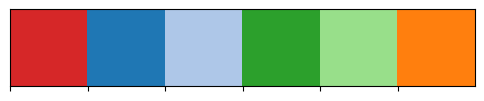

In [74]:
line_palette = {'True': '#d62728',
            'general': '#1f77b4',
            'general_eq': '#aec7e8',
            'subject_specific': '#2ca02c',
            'subject_specific_eq': '#98df8a',
            'parcel_specific': '#ff7f0e'
            }

sb.palplot(line_palette.values())


In [75]:
df_kappa_subject = recover_subject_kappa(df_kappa, n_subj)

/var/folders/y1/13zjm1t50ms6ds24c69y7vx40000gn/T/ipykernel_29914/200425064.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_kappa_subject['model_type'].loc[df_kappa_subject['comparison'] == 'kappa_true'] = 'True'


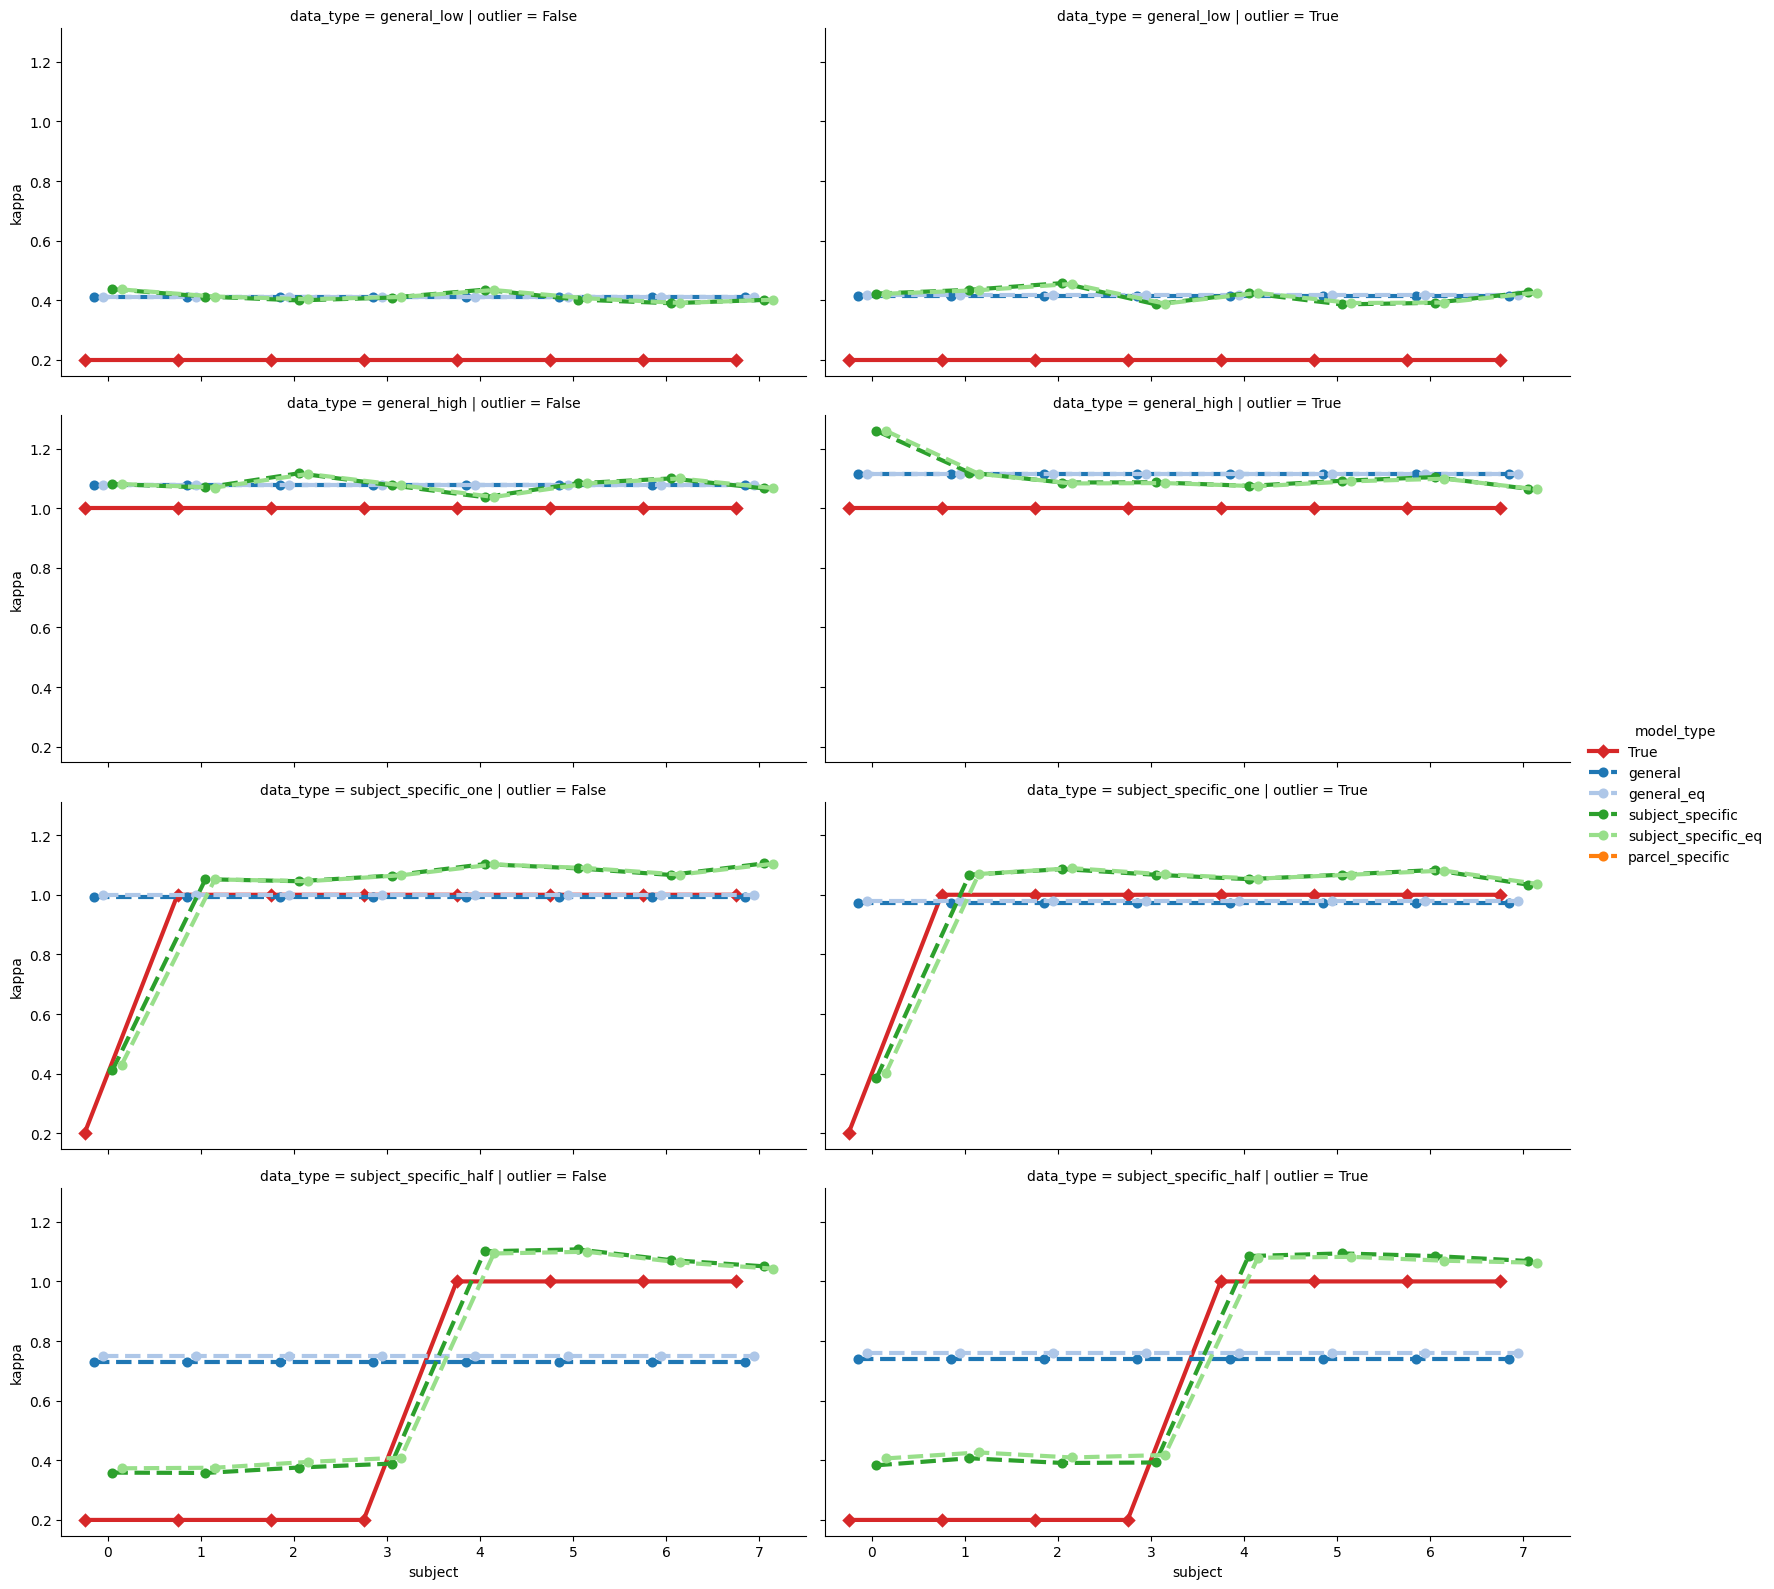

In [76]:
# Line plot to compare kappa_true and kappa_estimated

sb.catplot(
    data=df_kappa_subject, 
    x='subject', 
    y='kappa', 
    hue='model_type', 
    col='outlier', 
    row='data_type', 
    kind='point', 
    height=4, 
    aspect=2, 
    markers=['D', 'o', 'o', 'o', 'o', 'o'],  # You can adjust marker types as needed
    linestyles=['-', '--', '--', '--', '--', '--'],
    palette={'True': '#d62728',
            'general': '#1f77b4',
            'general_eq': '#aec7e8',
            'subject_specific': '#2ca02c',
            'subject_specific_eq': '#98df8a',
            'parcel_specific': '#ff7f0e'
            },  # Custom colors for hue levels
    hue_order=['True', 'general', 'general_eq', 'subject_specific', 'subject_specific_eq', 'parcel_specific'],  # Adjust order of hue levels
    dodge=0.5,          # Dodge overlapping points
    markersize=5,         # Increase marker size for better visibility
    linewidth=3,  # Adjust the line width as needed
    errorbar='sd'  # Add error bars
)
plt.savefig(figure_dir + f'{filename}_kappa.png')

In [77]:
df_uhat.head()

,model_type,data_type,outlier,simulation,comparison,Uhat_correct
128,general,general_low,True,1,correct_mean,66.21948
129,general_eq,general_low,True,1,correct_mean,66.159805
130,subject_specific,general_low,True,1,correct_mean,66.21399
131,subject_specific_eq,general_low,True,1,correct_mean,66.179016
132,general,general_low,False,2,correct_mean,66.30864


In [78]:
df_uhat.groupby(['model_type', 'data_type', 'outlier', 'comparison']).mean()

simulation  \
model_type          data_type            outlier comparison                        
general             general_high         False   correct_mean                4.0   
                                                 correct_mean_normal         4.0   
                                                 correct_outlier             4.0   
                                         True    correct_mean                3.0   
                                                 correct_mean_normal         3.0   
...                                                                          ...   
subject_specific_eq subject_specific_one False   correct_mean_normal         6.0   
                                                 correct_outlier             6.0   
                                         True    correct_mean                5.0   
                                                 correct_mean_normal         5.0   
                                                 correct_outlier             5.0   

                                                                     Uhat_correct  
model_type          data_type            outlier comparison                        
general             general_high         False   correct_mean           68.567215  
                                                 correct_mean_normal          NaN  
                                                 correct_outlier              NaN  
                                         True    correct_mean            67.62346  
                                                 correct_mean_normal    68.135605  
...                                                                           ...  
subject_specific_eq subject_specific_one False   correct_mean_normal          NaN  
                                                 correct_outlier              NaN  
                                         True    correct_mean            68.15364  
                                                 correct_mean_normal    68.390358  
                                                 correct_outlier        66.496567  

[96 rows x 2 columns]

In [79]:
# Sanity check for Uhat of general model, subject_specific_same-low data and no outlier
selection = df_uhat.query('data_type == "subject_specific_same-low"').query('outlier == False').query('model_type == "general"').query('comparison == "correct_mean"')
# calculate mean and std
mean = selection.Uhat_correct.mean()
std = selection.Uhat_correct.std()
print(mean, std)
selection

nan nan


,model_type,data_type,outlier,simulation,comparison,Uhat_correct


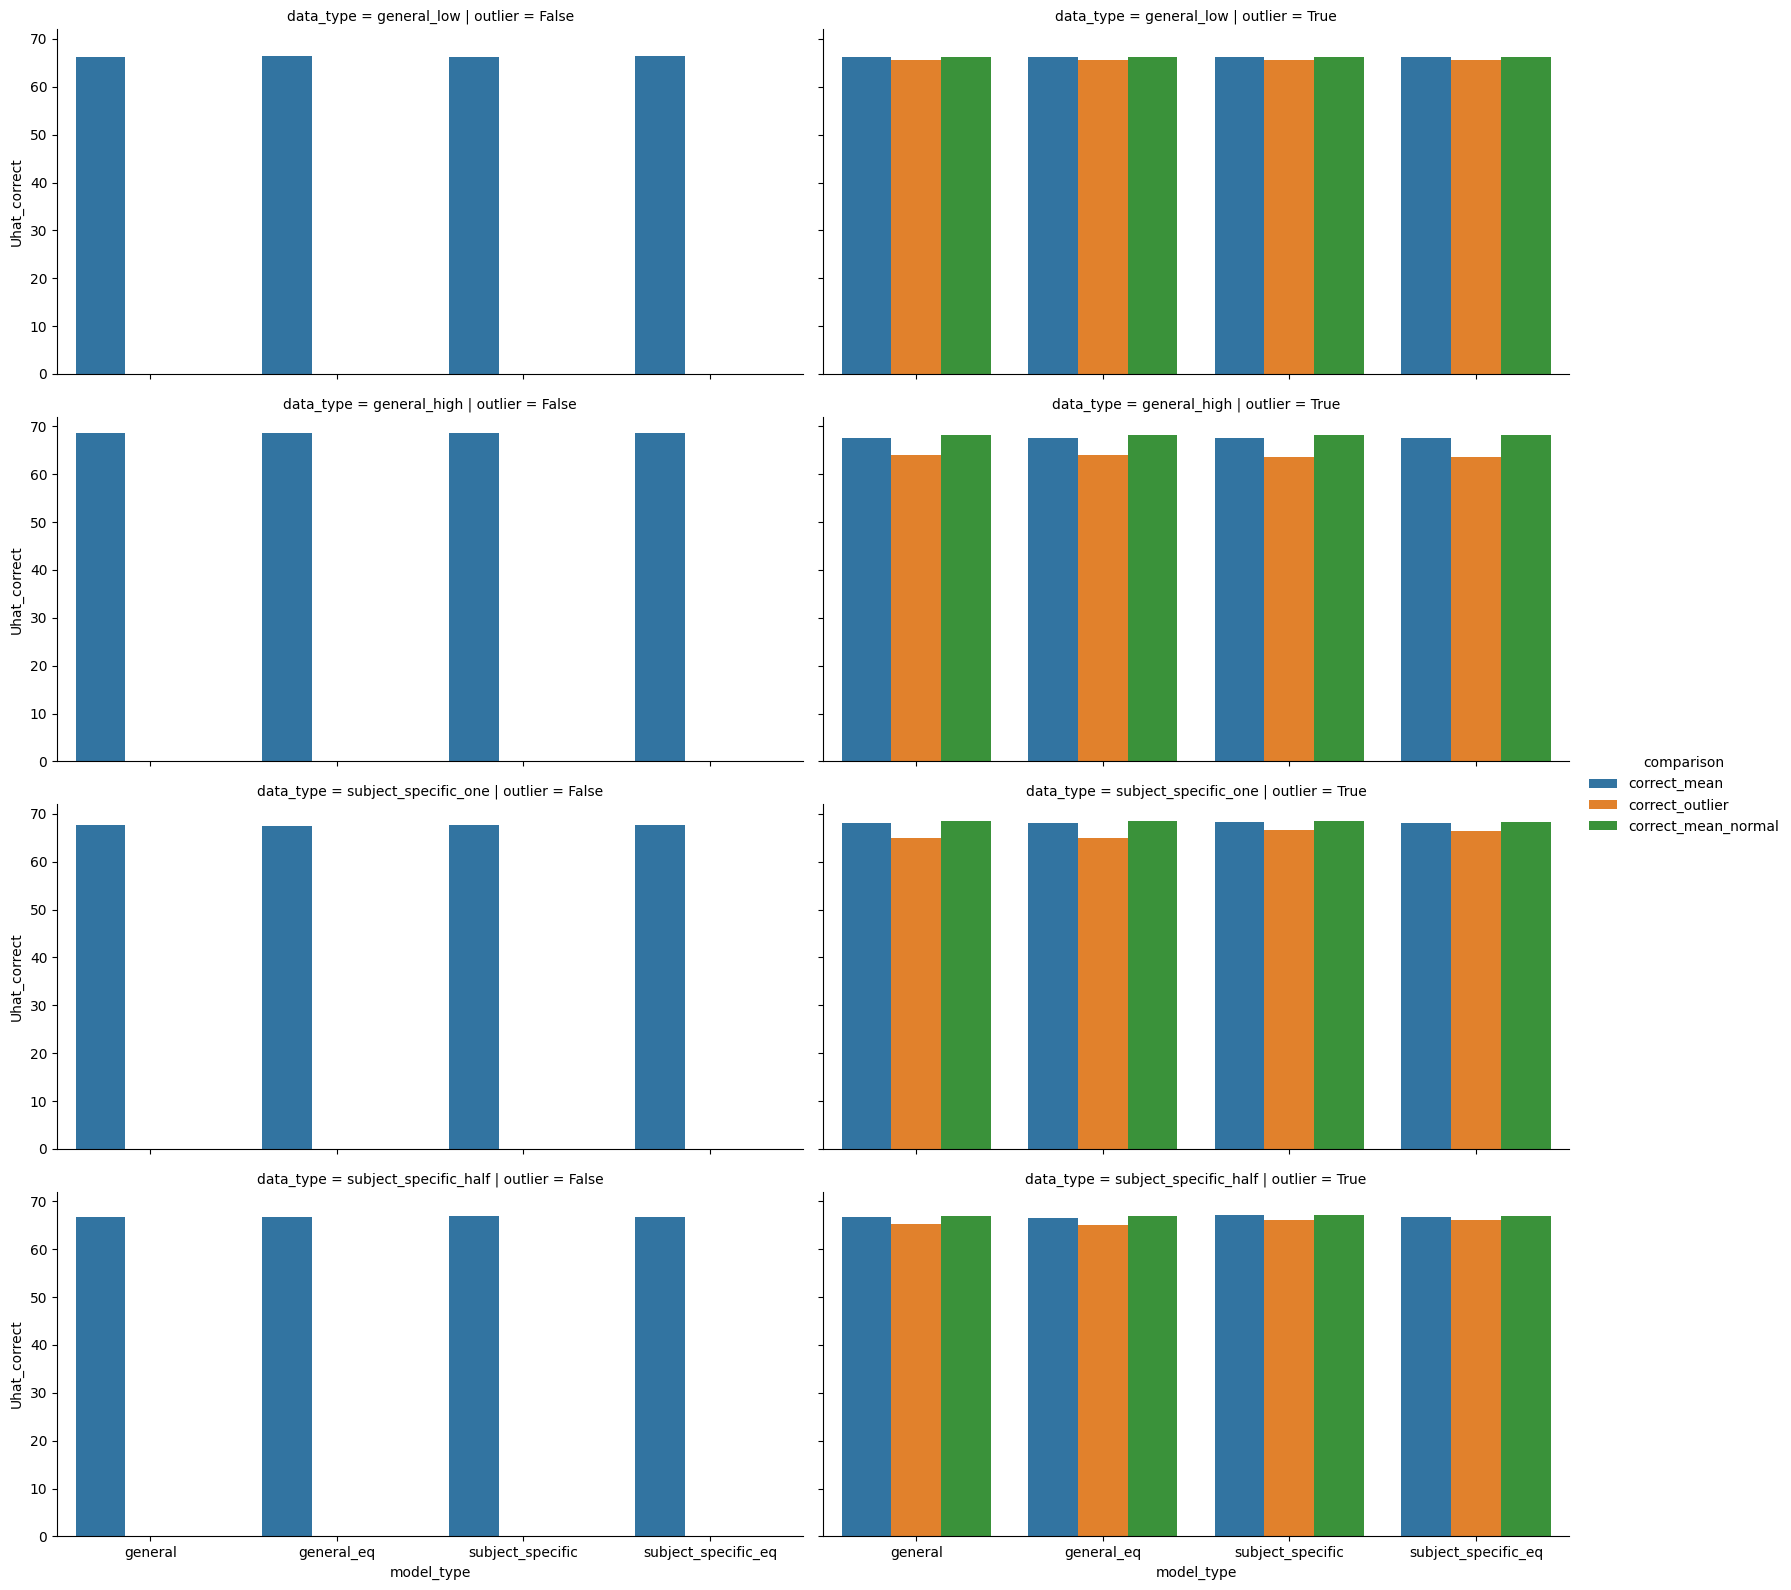

In [80]:
sb.catplot(data=df_uhat, x='model_type', y='Uhat_correct', hue='comparison', col='outlier', row='data_type', kind='bar', height=4, aspect=2)
figure_dir = paths.set_figure_dir()
plt.savefig(figure_dir + f'{filename}.png')

In [81]:
data_type='subject_specific_half'
table = df_uhat.query('data_type == @data_type').pivot_table(index=['model_type', 'outlier'], columns='comparison', values='Uhat_correct', aggfunc=['mean', 'std'])
table


mean                                    
comparison                  correct_mean correct_mean_normal correct_outlier
model_type          outlier                                                 
general             False       66.81481                 NaN             NaN
                    True       66.738686           66.955124       65.223595
general_eq          False       66.64335                 NaN             NaN
                    True        66.62071           66.858711       64.954735
subject_specific    False       67.03909                 NaN             NaN
                    True         67.0439           67.166763       66.183815
subject_specific_eq False       66.81962                 NaN             NaN
                    True        66.78189           66.884575       66.063103